<a href="https://colab.research.google.com/github/sindhura-nk/AI-Projects---1519/blob/main/Credit_Card_Default_Model_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Credit Card Default Model prediciton using Artificial Neural Network - ANN
### Build a model that will predict borrowers’ chance of defaulting on credit loans.

Change the runtime and Connect to GPU before executing
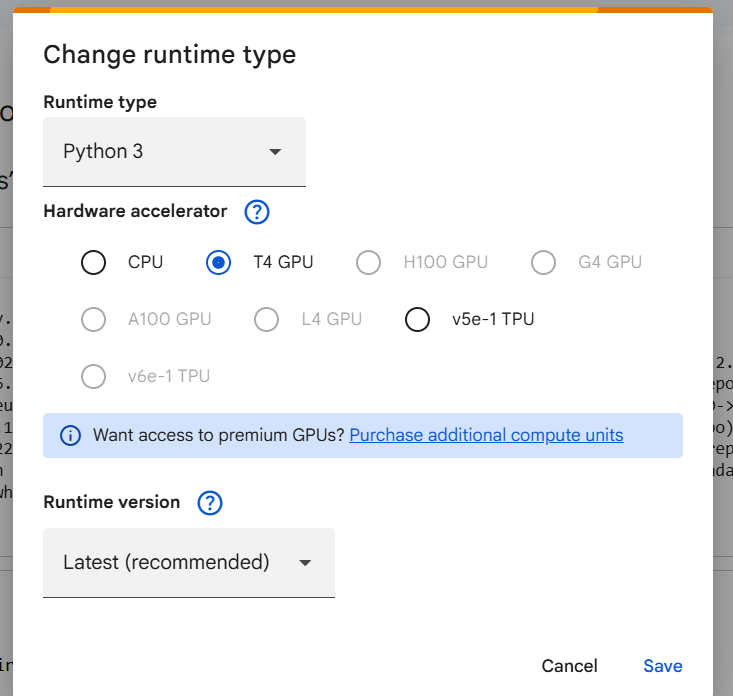

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [3]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [4]:
new_cols = ['Credit_Amount','Gender','Education','Marital status','Age','Repay_Sept','Repay_Aug','Repay_July','Repay_June','Repay_May','Repay_April',
            'Bill_Sept','Bill_Aug','Bill_July','Bill__June','Bill_May','Bill_April',
           'Amount_paid_Sept','Amount_paid_Aug','Amount_paid_July','Amount_paid_June','Amount_paid_May','Amount_paid_April']

In [5]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

In [6]:
X.columns = new_cols
X.columns

Index(['Credit_Amount', 'Gender', 'Education', 'Marital status', 'Age',
       'Repay_Sept', 'Repay_Aug', 'Repay_July', 'Repay_June', 'Repay_May',
       'Repay_April', 'Bill_Sept', 'Bill_Aug', 'Bill_July', 'Bill__June',
       'Bill_May', 'Bill_April', 'Amount_paid_Sept', 'Amount_paid_Aug',
       'Amount_paid_July', 'Amount_paid_June', 'Amount_paid_May',
       'Amount_paid_April'],
      dtype='object')

In [7]:
X.head()

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid_April
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [8]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [9]:
y.value_counts()

,count
Y,
0,23364
1,6636


In [10]:
((y.value_counts())/len(y))*100

,count
Y,
0,77.88
1,22.12


<Axes: xlabel='Y'>

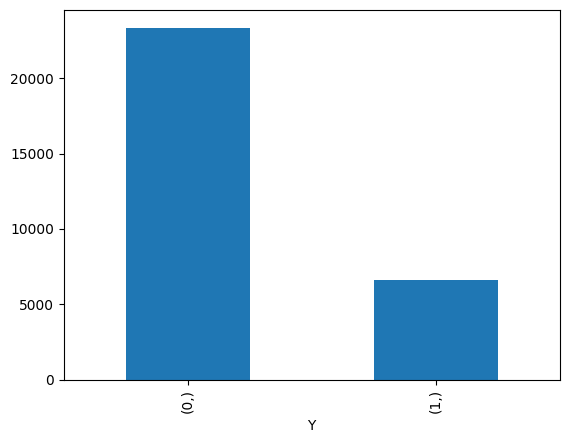

In [11]:
y.value_counts().plot(kind='bar')

## This dataset has imbalanced data for target features

In [12]:
len(y)

30000

In [13]:
X.head(2)

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid_April
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000


In [14]:
X.dtypes

,0
Credit_Amount,int64
Gender,int64
Education,int64
Marital status,int64
Age,int64
Repay_Sept,int64
Repay_Aug,int64
Repay_July,int64
Repay_June,int64
Repay_May,int64


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

num_pipe = make_pipeline(SimpleImputer(strategy='mean'),
                         StandardScaler()
                         ).set_output(transform='pandas')
X_pre = num_pipe.fit_transform(X)
X_pre.head()


,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid_April
0,-1.136720,0.810161,0.185828,-1.057295,-1.246020,1.794564,1.782348,-0.696663,-0.666599,-1.530046,...,-0.667993,-0.672497,-0.663059,-0.652724,-0.341942,-0.227086,-0.296801,-0.308063,-0.314136,-0.293382
1,-0.365981,0.810161,0.185828,0.858557,-1.029047,-0.874991,1.782348,0.138865,0.188746,0.234917,...,-0.639254,-0.621636,-0.606229,-0.597966,-0.341942,-0.213588,-0.240005,-0.244230,-0.314136,-0.180878
2,-0.597202,0.810161,0.185828,0.858557,-0.161156,0.014861,0.111736,0.138865,0.188746,0.234917,...,-0.482408,-0.449730,-0.417188,-0.391630,-0.250292,-0.191887,-0.240005,-0.244230,-0.248683,-0.012122
3,-0.905498,0.810161,0.185828,-1.057295,0.164303,0.014861,0.111736,0.138865,0.188746,0.234917,...,0.032846,-0.232373,-0.186729,-0.156579,-0.221191,-0.169361,-0.228645,-0.237846,-0.244166,-0.237130
4,-0.905498,-1.234323,0.185828,-1.057295,2.334029,-0.874991,0.111736,-0.696663,0.188746,0.234917,...,-0.161189,-0.346997,-0.348137,-0.331482,-0.221191,1.335034,0.271165,0.266434,-0.269039,-0.255187


In [16]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,y,train_size=0.7,random_state=21)

## Balance the Y samples using SMOTE technique

In [17]:
pip install imblearn

In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_sampl,y_sampl = smote.fit_resample(xtrain,ytrain)

In [19]:
y_sampl.value_counts()

,count
Y,
0,16364
1,16364


In [20]:
xtrain.shape

(21000, 23)

In [21]:
xtrain.shape[1]

23

## Build Neural Network model

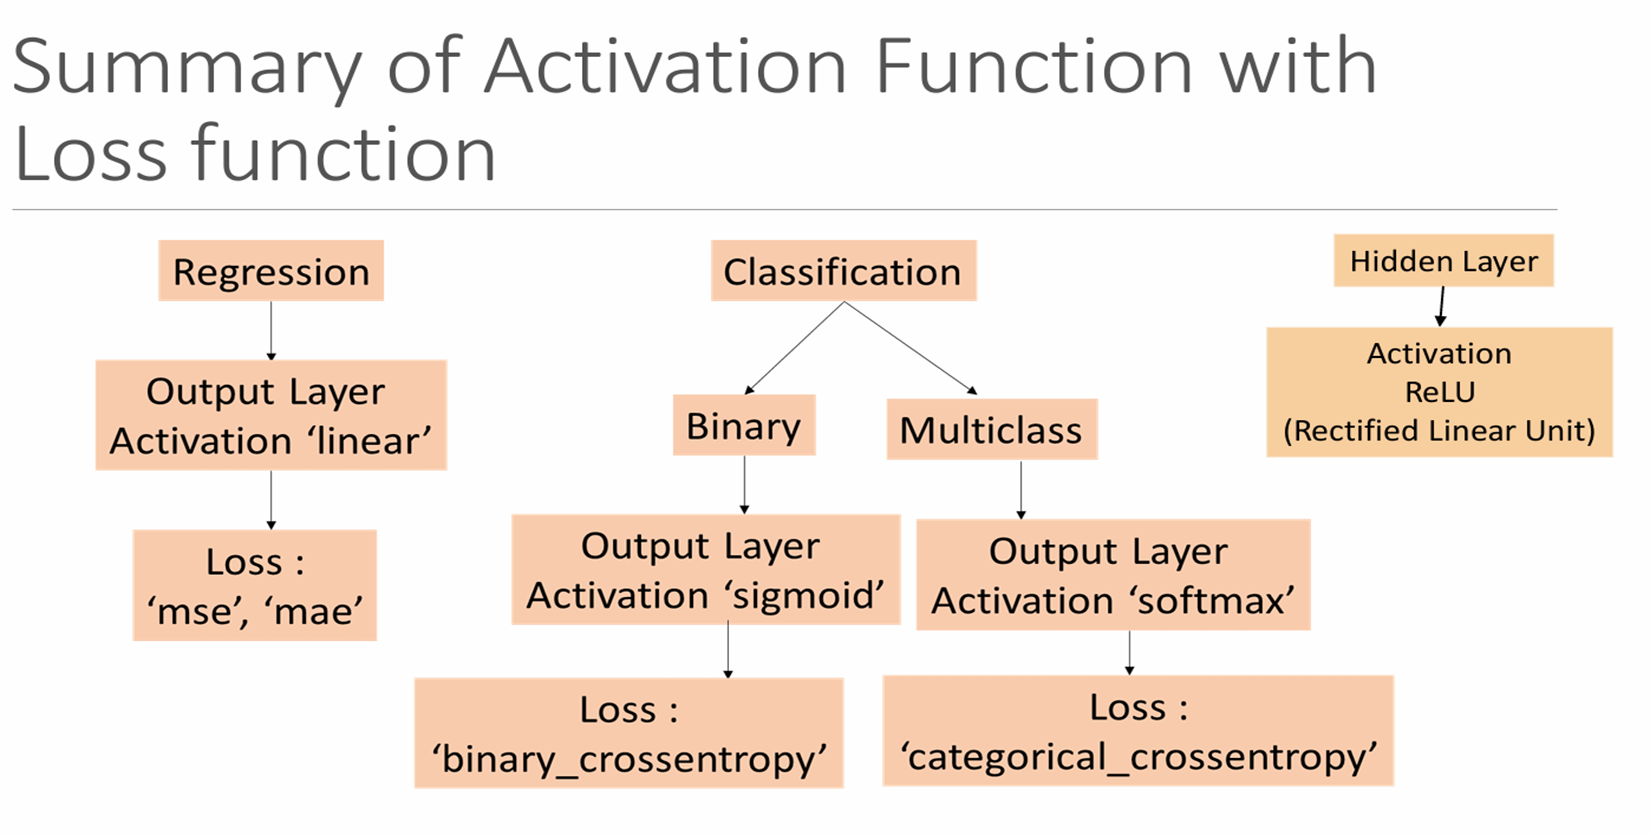

In [22]:
from keras.models import Sequential
from keras.layers import Input,Dense

In [23]:
# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer1
model.add(Dense(units=64,activation='relu'))

# Add the Hidden layer2
model.add(Dense(units=32,activation='relu'))

# Add the Output layer
model.add(Dense(units=1,activation='sigmoid'))

In [24]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
len(y_sampl)

32728

In [26]:
(20*len(y_sampl))/100

6545.6

In [27]:
nn = model.fit(x_sampl,y_sampl,validation_split=0.2,epochs=50)
# 20% trianing data is split => validation
# 20% of 32728 = used for validation

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7223 - loss: 0.5850 - val_accuracy: 0.4581 - val_loss: 0.8611
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7412 - loss: 0.5475 - val_accuracy: 0.5189 - val_loss: 0.6957
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7467 - loss: 0.5340 - val_accuracy: 0.4849 - val_loss: 0.8242
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7494 - loss: 0.5246 - val_accuracy: 0.5053 - val_loss: 0.7528
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7534 - loss: 0.5195 - val_accuracy: 0.5373 - val_loss: 0.6992
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7471 - loss: 0.5267 - val_accuracy: 0.5237 - val_loss: 0.7662
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7488 - loss: 0.5219 - val_accuracy: 0.5816 - val_loss: 0.6740
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7568 - loss: 0.5087 - val_accuracy: 0.

## Learning Curve

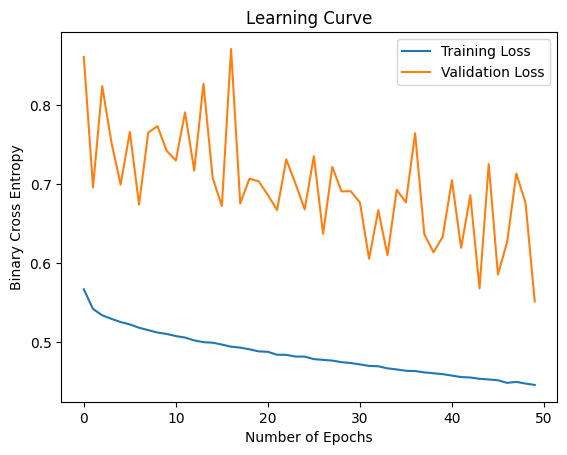

In [28]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.ylabel("Binary Cross Entropy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [29]:
model.evaluate(xtest,ytest)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7610 - loss: 0.5512


[0.5431544184684753, 0.7591111063957214]

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
ypreds = model.predict(xtest)
ypreds[:10]

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.6664157 ],
       [0.6296559 ],
       [0.1596571 ],
       [0.17742987],
       [0.0462088 ],
       [0.28912383],
       [0.5249327 ],
       [0.05901795],
       [0.78093594],
       [0.04265005]], dtype=float32)

In [31]:
ytest.head()

,Y
6677,0
20672,1
19682,0
23589,0
16352,1


In [32]:
ypreds_new = []
for i in ypreds:
  if i>0.5:
    ypreds_new.append(1)
  else:
    ypreds_new.append(0)
ypreds_new[:10]

[1, 1, 0, 0, 0, 0, 1, 0, 1, 0]

In [34]:
ytest.value_counts()

,count
Y,
0,7000
1,2000


In [37]:
from sklearn.metrics import classification_report
print(classification_report(ytest,ypreds_new))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      7000
           1       0.47      0.57      0.51      2000

    accuracy                           0.76      9000
   macro avg       0.67      0.69      0.68      9000
weighted avg       0.78      0.76      0.77      9000

